In [1]:
import numpy as np
import bayesflow as bf
import keras
from pathlib import Path

INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
bf.__version__

'2.0.12'

In [3]:
RNG=np.random.default_rng(2025)
num_dims=20
num_obs=50
mu_prior_mean1=0
mu_prior_mean2=0.5
mu_prior_std=1
likelihood_std=1
student_df=3

In [4]:
def prior_0():
    mu=RNG.normal(loc=mu_prior_mean1,scale=mu_prior_std,size=num_dims)
    return dict(mu=mu)
def prior_10():
    mu=RNG.normal(loc=mu_prior_mean2,scale=mu_prior_std,size=num_dims)
    return dict(mu=mu)
def likelihood_n(mu):
    x=RNG.normal(loc=mu,scale=likelihood_std,size=(num_obs,num_dims))
    return dict(x=x)
def likelihood_t(mu):
    scale = likelihood_std * np.sqrt((student_df - 2) / student_df)
    x=RNG.standard_t(df=student_df, size=(num_obs,num_dims))*scale+mu
    return dict(x=x)

simulator_1=bf.make_simulator([prior_0,likelihood_n])
simulator_2=bf.make_simulator([prior_10,likelihood_n])
simulator_3=bf.make_simulator([prior_0,likelihood_t])
simulator=bf.simulators.ModelComparisonSimulator(
    simulators=[simulator_1,simulator_2,simulator_3],
    use_mixed_batches=True,
    )


In [5]:
data = simulator.sample(100)
for key, value in data.items():
    print(key + " shape:", np.array(value).shape)

mu shape: (100, 20)
x shape: (100, 50, 20)
model_indices shape: (100, 3)


In [6]:
# adapter 
adapter = (bf.Adapter()
           .as_set("x")
           .convert_dtype("float64", "float32")
           .rename('x', 'summary_variables')
           .rename('model_indices', 'inference_variables')
                )

In [7]:
# networks
summary_network = bf.networks.DeepSet(summary_dim=6*num_dims)
classifier_network = bf.networks.MLP()

In [8]:
approximator = bf.approximators.ModelComparisonApproximator(
            num_models=3,
            classifier_network=classifier_network,
            summary_network=summary_network,
            adapter=adapter,
            standardize="all",  
        )

In [9]:
epochs=200
batch_size=200
num_batches_per_epoch=300
learning_rate=keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=1e-4, 
            decay_steps=epochs * num_batches_per_epoch
            )
approximator.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate))

In [10]:
history = approximator.fit(simulator=simulator,adapter=adapter,
                           epochs=epochs,batch_size=batch_size,num_batches=num_batches_per_epoch,)

INFO:bayesflow:Building dataset from simulator instance of ModelComparisonSimulator.
INFO:bayesflow:Using 12 data loading workers.
INFO:bayesflow:Building on a test batch.


Epoch 1/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - cross_entropy/inference_cross_entropy: 0.9093 - loss: 0.9093
Epoch 2/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - cross_entropy/inference_cross_entropy: 0.7896 - loss: 0.7896
Epoch 3/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - cross_entropy/inference_cross_entropy: 0.8423 - loss: 0.8423
Epoch 4/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - cross_entropy/inference_cross_entropy: 0.8575 - loss: 0.8575
Epoch 5/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - cross_entropy/inference_cross_entropy: 0.7965 - loss: 0.7965
Epoch 6/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - cross_entropy/inference_cross_entropy: 0.7971 - loss: 0.7971
Epoch 7/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - cross_entropy/inference_cross_entropy: 0.7788 - loss: 0.7788
Epoch 8/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - cross_entropy/inference_cross_entropy: 0.7162 - loss: 0.7162
Epoch 9/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step -

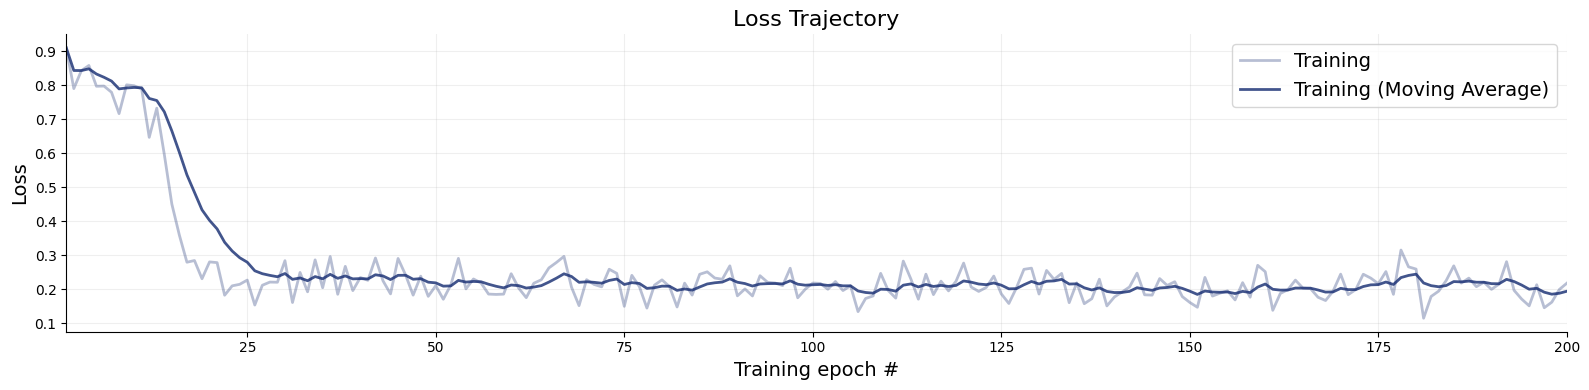

In [11]:
f=bf.diagnostics.plots.loss(history)

In [12]:
val_df=simulator.sample(5000)
pred_models = approximator.predict(conditions=val_df, probs=True)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


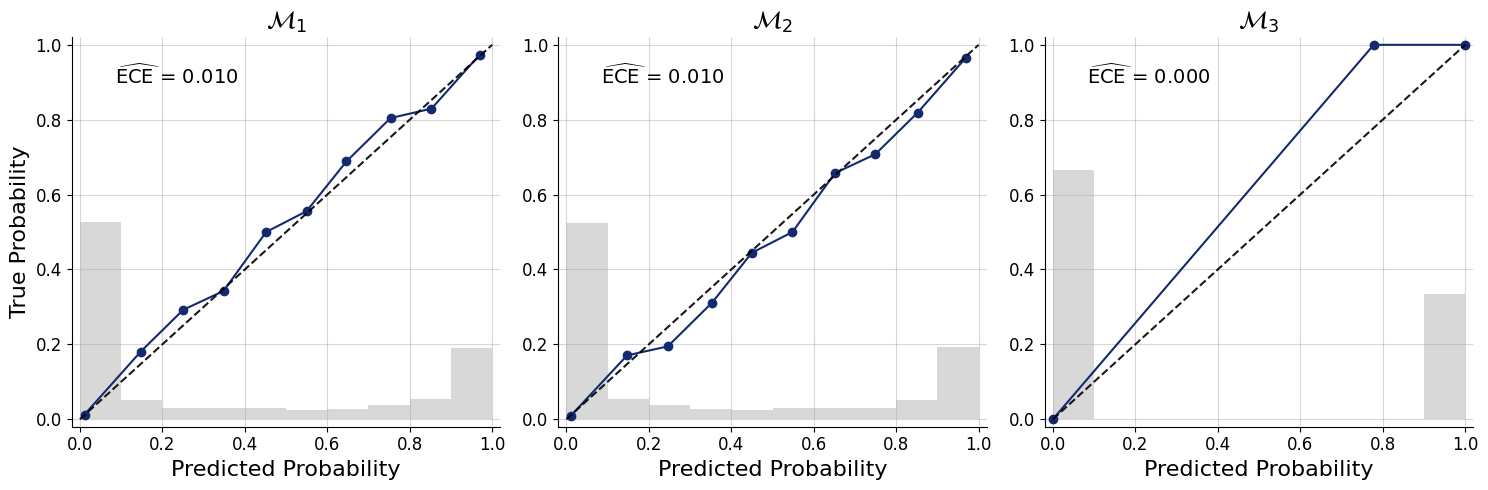

In [13]:
f = bf.diagnostics.plots.mc_calibration(
    pred_models=pred_models,
    true_models=val_df["model_indices"],
    model_names=[r"$\mathcal{M}_1$", r"$\mathcal{M}_2$",r"$\mathcal{M}_3$"],
)

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


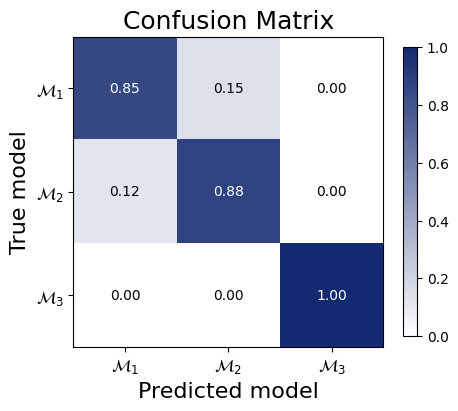

In [14]:
f = bf.diagnostics.plots.mc_confusion_matrix(
    pred_models=pred_models,
    true_models=val_df["model_indices"],
    model_names=[r"$\mathcal{M}_1$", r"$\mathcal{M}_2$",r"$\mathcal{M}_3$"],
    normalize="true",
)

In [15]:
# Save the trained approximator
filepath = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks") / "direct.keras"
filepath.parent.mkdir(exist_ok=True)
approximator.save(filepath=filepath)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


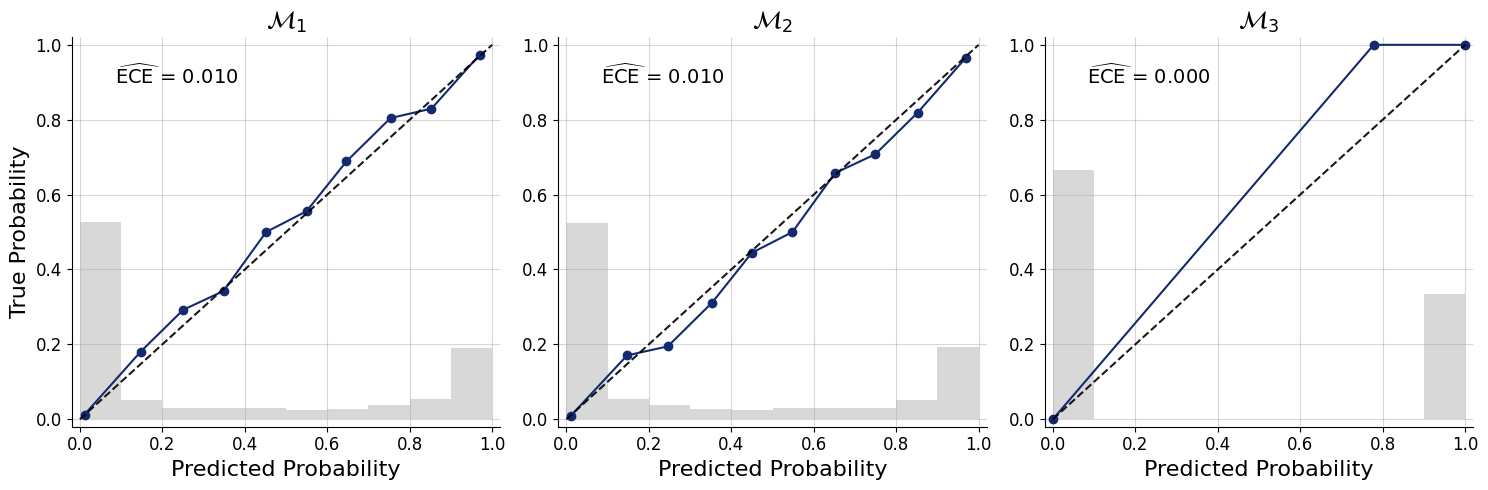

In [16]:
# Load approximator
filepath = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks") / "direct.keras"
approximator = keras.saving.load_model(filepath)
pred_models = approximator.predict(conditions=val_df, probs=True)
f = bf.diagnostics.plots.mc_calibration(
    pred_models=pred_models,
    true_models=val_df["model_indices"],
    model_names=[r"$\mathcal{M}_1$", r"$\mathcal{M}_2$",r"$\mathcal{M}_3$"],
)